# Connect to Google Colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_path = '/content/drive/MyDrive/final_project'
os.makedirs(project_path, exist_ok=True)

# Import dependencies

In [4]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import LinearSVC
import string
import scipy.sparse as sp
import shap
import joblib
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline, EarlyStoppingCallback

In [5]:
# Load the dataset from cleaning steps (select the appropriate code according to the use)
df = pd.read_csv(f"{project_path}/drug-reviews-cleaned.csv")
#df = pd.read_csv("data/drug-reviews-cleaned.csv")

## dmis-lab/biobert-base-cased-v1.1

In [6]:
# Binary labels: 0 = negative, 1 = non-negative
df["Label_binary"] = df["Label"].map({0: 0, 1: 1, 2: 1})

In [7]:
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear,Label,reviews_clean,reviews_no_stopwords,reviews_lemmatized,Label_binary
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021,1,this is very effective if you can get the cove...,effective get cover,effective get cover,1
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022,2,actually use the generic brand of the 12 hour ...,actually use generic brand 12 hour nasal spray...,actually use generic brand 12 hour nasal spray...,1
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018,0,cap took 20 minutes to open process was frustr...,cap took 20 minutes open process frustrating p...,cap took 20 minute open process frustrating pa...,0
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020,2,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...,1
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019,2,took ssri prozac for anxiety depression for 18...,took ssri prozac anxiety depression 18 years s...,took ssri prozac anxiety depression 18 year si...,1


In [8]:
X = df['Reviews']
y = df['Label_binary']

# Split data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

print(f"X original shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"y original shape: {y.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X original shape: (386137,)
X_train shape: (308909,)
X_test shape: (77228,)
y original shape: (386137,)
y_train shape: (308909,)
y_test shape: (77228,)


In [9]:
dataset = DatasetDict({ "train": Dataset.from_dict({ "Reviews": X_train.tolist(),
                                                    "labels": y_train.tolist(), }),
                        "test": Dataset.from_dict({ "Reviews": X_test.tolist(),
                                                   "labels": y_test.tolist(), }),
                        })
dataset

DatasetDict({
    train: Dataset({
        features: ['Reviews', 'labels'],
        num_rows: 308909
    })
    test: Dataset({
        features: ['Reviews', 'labels'],
        num_rows: 77228
    })
})

In [10]:
id2label = {0: "Negative", 1: "Non-negative"}
label2id = {"Negative": 0, "Non-negative": 1}

In [11]:
model = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1",
                                                           num_labels=2,
                                                            id2label=id2label,
                                                            label2id=label2id)
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [12]:
def tokenize_dataset(dataset):
    return tokenizer(dataset["Reviews"],
                     truncation=True,
                     max_length=511)

dataset = dataset.map(tokenize_dataset, batched=True)


dataset

Map:   0%|          | 0/308909 [00:00<?, ? examples/s]

Map:   0%|          | 0/77228 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Reviews', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 308909
    })
    test: Dataset({
        features: ['Reviews', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 77228
    })
})

In [13]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [13]:
training_args = TrainingArguments(
    output_dir=(f"{project_path}/biobert-drug-reviews-binary"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    bf16=True
)

In [14]:
# F1 macro
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    f1_macro = f1_score(
        labels,
        predictions,
        average='macro'
    )

    return {
        "f1_macro": f1_macro
    }

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.295878,0.292082,0.864476
2,0.215211,0.269391,0.887918
3,0.159367,0.323214,0.901037


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=57921, training_loss=0.24271326566754683, metrics={'train_runtime': 5656.5142, 'train_samples_per_second': 163.834, 'train_steps_per_second': 10.24, 'total_flos': 9.962184886315571e+16, 'train_loss': 0.24271326566754683, 'epoch': 3.0})

In [16]:
trainer.save_model(f"{project_path}/biobert-drug-reviews-binary")
tokenizer.save_pretrained(f"{project_path}/biobert-drug-reviews-binary")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/final_project/biobert-drug-reviews-binary/tokenizer_config.json',
 '/content/drive/MyDrive/final_project/biobert-drug-reviews-binary/tokenizer.json')

In [17]:
predictions = trainer.predict(dataset['test'])
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

In [18]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds))
print(confusion_matrix(true_labels, preds))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.9116123685709846
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     26268
           1       0.93      0.94      0.93     50960

    accuracy                           0.91     77228
   macro avg       0.90      0.90      0.90     77228
weighted avg       0.91      0.91      0.91     77228

[[22578  3690]
 [ 3136 47824]]


In [19]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", round(accuracy_score(true_labels, preds),3))
print("F1 Macro:", round(f1_score(true_labels, preds, average='macro'), 3))
print("F1 Weighted:", round(f1_score(true_labels, preds,  average='weighted'), 3))
print("Class 0 Recall Score:", round(recall_score(true_labels, preds, labels=[0], average=None)[0], 3))
print("Class 0 F1 Score:", round(f1_score(true_labels, preds, labels=[0], average=None)[0], 3))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.912
F1 Macro: 0.901
F1 Weighted: 0.911
Class 0 Recall Score: 0.86
Class 0 F1 Score: 0.869


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Non-negative"], yticklabels=["Negative", "Non-negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('biobert_binary_cm_heatmap.png')
plt.show()

NameError: name 'confusion_matrix' is not defined

In [21]:
history = pd.DataFrame(
    trainer.state.log_history
)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.495072,9.579458,0.000020,0.025897,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.399018,6.681751,0.000020,0.051795,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.387880,11.494452,0.000019,0.077692,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.385924,3.641112,0.000019,0.103589,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.367457,5.187143,0.000019,0.129487,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


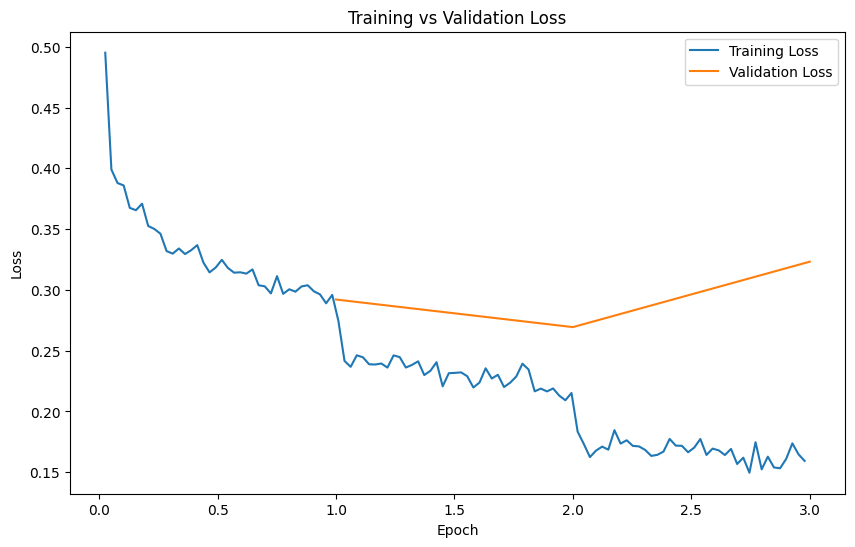

In [22]:
# Keep rows with losses
loss_history = history[
    history['loss'].notna()
]

eval_history = history[
    history['eval_loss'].notna()
]

plt.figure(figsize=(10,6))

# Training loss
plt.plot(
    loss_history['epoch'],
    loss_history['loss'],
    label='Training Loss'
)

# Validation loss
plt.plot(
    eval_history['epoch'],
    eval_history['eval_loss'],
    label='Validation Loss'
)

# Labels
plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [15]:
training_args_2 = TrainingArguments(
    output_dir=(f"{project_path}/biobert-drug-reviews-binary"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    bf16=True,
    weight_decay=0.01, #l2 regularization
    lr_scheduler_type="reduce_lr_on_plateau",
    lr_scheduler_kwargs={"mode": "max", #max for f1 and min for eval_loss
                         "factor": 0.1,
                         "patience": 0
                         }
)

In [16]:
trainer_2 = Trainer(
    model=model,
    args=training_args_2,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer_2.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.298716,0.288119,0.862994
2,0.245070,0.270628,0.879829
3,0.203676,0.258840,0.893832


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=57921, training_loss=0.2625514628287395, metrics={'train_runtime': 5708.7345, 'train_samples_per_second': 162.335, 'train_steps_per_second': 10.146, 'total_flos': 9.962184886315571e+16, 'train_loss': 0.2625514628287395, 'epoch': 3.0})

In [17]:
trainer_2.save_model(f"{project_path}/biobert-drug-reviews-binary_2")
tokenizer.save_pretrained(f"{project_path}/biobert-drug-reviews-binary_2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/final_project/biobert-drug-reviews-binary_2/tokenizer_config.json',
 '/content/drive/MyDrive/final_project/biobert-drug-reviews-binary_2/tokenizer.json')

In [20]:
predictions_2 = trainer_2.predict(dataset['test'])
preds_2 = predictions_2.predictions.argmax(axis=1)
true_labels_2 = predictions_2.label_ids

In [21]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", accuracy_score(true_labels_2, preds_2))
print(classification_report(true_labels_2, preds_2))
print(confusion_matrix(true_labels_2, preds_2))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.9046977780079763
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     26268
           1       0.93      0.93      0.93     50960

    accuracy                           0.90     77228
   macro avg       0.89      0.89      0.89     77228
weighted avg       0.90      0.90      0.90     77228

[[22581  3687]
 [ 3673 47287]]


In [22]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", round(accuracy_score(true_labels_2, preds_2),3))
print("F1 Macro:", round(f1_score(true_labels_2, preds_2, average='macro'), 3))
print("F1 Weighted:", round(f1_score(true_labels_2, preds_2,  average='weighted'), 3))
print("Class 0 Recall Score:", round(recall_score(true_labels_2, preds_2, labels=[0], average=None)[0], 3))
print("Class 0 F1 Score:", round(f1_score(true_labels_2, preds_2, labels=[0], average=None)[0], 3))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.905
F1 Macro: 0.894
F1 Weighted: 0.905
Class 0 Recall Score: 0.86
Class 0 F1 Score: 0.86


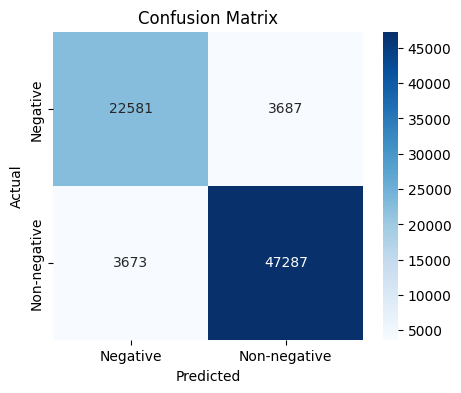

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_2 = confusion_matrix(true_labels_2, preds_2)

plt.figure(figsize=(5,4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Non-negative"], yticklabels=["Negative", "Non-negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('biobert_binary_cm_heatmap_2.png')
plt.show()

In [24]:
history_2 = pd.DataFrame(
    trainer_2.state.log_history
)

history_2.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.512858,10.901105,0.00002,0.025897,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.402975,7.605635,0.00002,0.051795,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.392049,8.873697,0.00002,0.077692,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.385942,4.335416,0.00002,0.103589,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.370595,5.494987,0.00002,0.129487,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


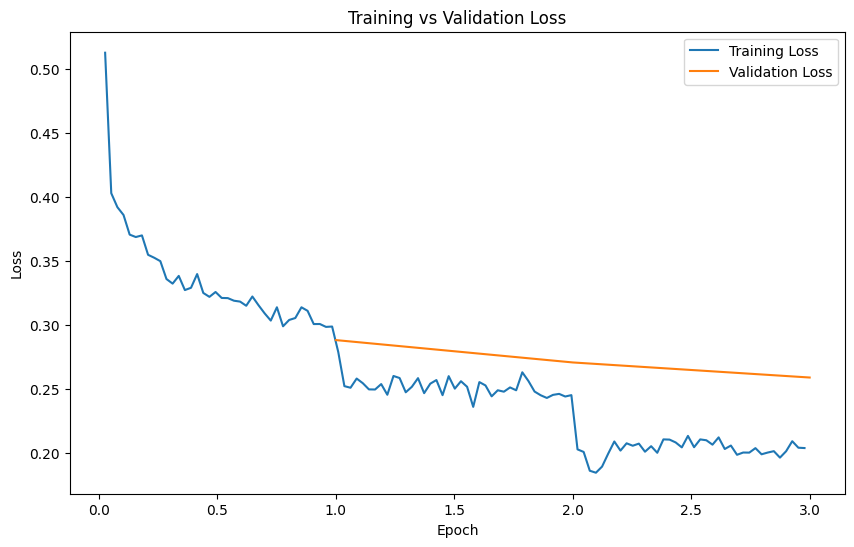

In [25]:
# Keep rows with losses
loss_history_2 = history_2[
    history_2['loss'].notna()
]

eval_history_2 = history_2[
    history_2['eval_loss'].notna()
]

plt.figure(figsize=(10,6))

# Training loss
plt.plot(
    loss_history_2['epoch'],
    loss_history_2['loss'],
    label='Training Loss'
)

# Validation loss
plt.plot(
    eval_history_2['epoch'],
    eval_history_2['eval_loss'],
    label='Validation Loss'
)

# Labels
plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [26]:
# Increase epochs
training_args_3 = TrainingArguments(
    output_dir=(f"{project_path}/biobert-drug-reviews-binary_3"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    bf16=True,
    weight_decay=0.01, #l2 regularization
    lr_scheduler_type="reduce_lr_on_plateau",
    lr_scheduler_kwargs={"mode": "max", #max for f1 and min for eval_loss
                         "factor": 0.1,
                         "patience": 0
                         }
)

In [27]:
trainer_3 = Trainer(
    model=model,
    args=training_args_3,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer_3.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.144658,0.394473,0.901066
2,0.111859,0.422876,0.903158
3,0.111782,0.392238,0.906545
4,0.133722,0.364595,0.907560
5,0.124270,0.386797,0.916567


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=96535, training_loss=0.12393711948281166, metrics={'train_runtime': 9510.842, 'train_samples_per_second': 162.398, 'train_steps_per_second': 10.15, 'total_flos': 1.660570414110741e+17, 'train_loss': 0.12393711948281166, 'epoch': 5.0})

In [28]:
trainer_3.save_model(f"{project_path}/biobert-drug-reviews-binary_3")
tokenizer.save_pretrained(f"{project_path}/biobert-drug-reviews-binary_3")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/final_project/biobert-drug-reviews-binary_3/tokenizer_config.json',
 '/content/drive/MyDrive/final_project/biobert-drug-reviews-binary_3/tokenizer.json')

In [29]:
predictions_3 = trainer_3.predict(dataset['test'])
preds_3 = predictions_3.predictions.argmax(axis=1)
true_labels_3 = predictions_3.label_ids

In [30]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", accuracy_score(true_labels_3, preds_3))
print(classification_report(true_labels_3, preds_3))
print(confusion_matrix(true_labels_3, preds_3))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.9247293727663541
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     26268
           1       0.95      0.94      0.94     50960

    accuracy                           0.92     77228
   macro avg       0.91      0.92      0.92     77228
weighted avg       0.93      0.92      0.92     77228

[[23630  2638]
 [ 3175 47785]]


In [31]:
print("Trainer Class biobert-base-cased-v1.1")
print("Accuracy:", round(accuracy_score(true_labels_3, preds_3),3))
print("F1 Macro:", round(f1_score(true_labels_3, preds_3, average='macro'), 3))
print("F1 Weighted:", round(f1_score(true_labels_3, preds_3,  average='weighted'), 3))
print("Class 0 Recall Score:", round(recall_score(true_labels_3, preds_3, labels=[0], average=None)[0], 3))
print("Class 0 F1 Score:", round(f1_score(true_labels_3, preds_3, labels=[0], average=None)[0], 3))

Trainer Class biobert-base-cased-v1.1
Accuracy: 0.925
F1 Macro: 0.917
F1 Weighted: 0.925
Class 0 Recall Score: 0.9
Class 0 F1 Score: 0.89


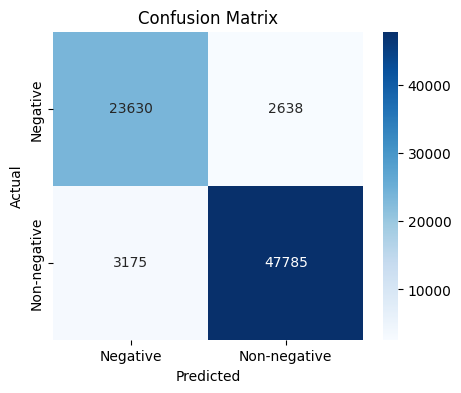

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_3 = confusion_matrix(true_labels_3, preds_3)

plt.figure(figsize=(5,4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Non-negative"], yticklabels=["Negative", "Non-negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('biobert_binary_cm_heatmap_2.png')
plt.show()

In [33]:
history_3 = pd.DataFrame(
    trainer_3.state.log_history
)

history_3.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.161283,0.513715,0.00002,0.025897,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.150631,0.287846,0.00002,0.051795,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.165821,25.012146,0.00002,0.077692,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.158489,9.771747,0.00002,0.103589,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.155539,0.525546,0.00002,0.129487,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


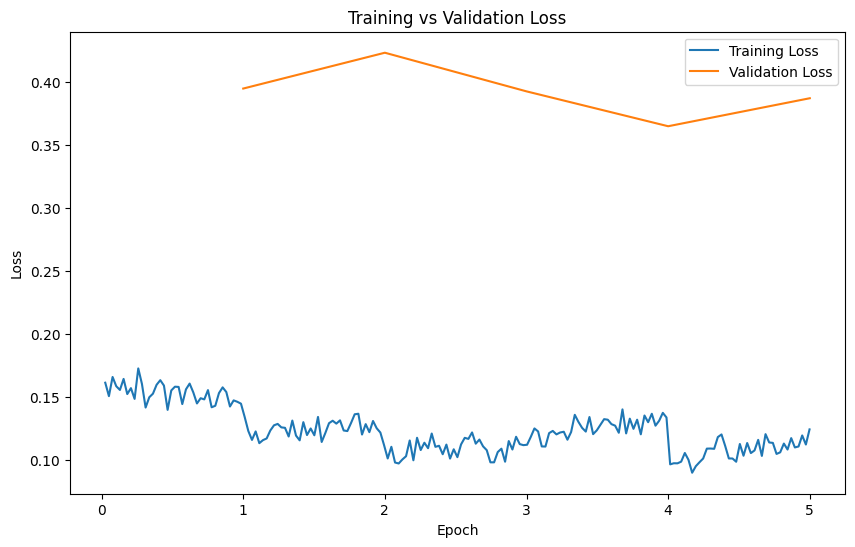

In [34]:
# Keep rows with losses
loss_history_3 = history_3[
    history_3['loss'].notna()
]

eval_history_3 = history_3[
    history_3['eval_loss'].notna()
]

plt.figure(figsize=(10,6))

# Training loss
plt.plot(
    loss_history_3['epoch'],
    loss_history_3['loss'],
    label='Training Loss'
)

# Validation loss
plt.plot(
    eval_history_3['epoch'],
    eval_history_3['eval_loss'],
    label='Validation Loss'
)

# Labels
plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()